In [1]:
import os
import sys
import platform

sys.path.append(os.path.dirname(os.getcwd()))
from benchmark_utils.sync_utils import plotFramesShiftToSyncrhonizeAllSubjectsOneActivity,getMainJointFromMotAndMainBonesFromCSV, getSamplesToSynchronize, SynchronizeAndCutSignals
from benchmark_utils.compare_utils import *
import benchmark_utils.file_utils as fileutil 
import benchmark_utils.plot_utils as plotutil
import benchmark_utils.signal_utils as signalutil

In [2]:

if platform.system() == "Linux":
    dataset_path = '/mnt/d/vidimu_pipeline/VIDIMU'
elif platform.system() == "Darwin":
    dataset_path = '/Volumes/Aux/vidimu_pipeline/VIDIMU'

in_path_bodytrack = os.path.join(dataset_path,'benchmark','dataset_bodytrack')
in_path_motionbert = os.path.join(dataset_path,'benchmark','dataset_motionbert')
in_path_motionagformer = os.path.join(dataset_path,'benchmark','dataset_motionagformer')
in_path_imus = os.path.join(dataset_path,'benchmark','dataset_imus')
out_path = os.path.join(dataset_path,'benchmark','comparison')
if not os.path.exists(out_path):
    os.makedirs(out_path)

lower_activities = ["A01","A02","A03","A04"]
upper_activities = ["A05","A06","A07","A08","A09","A10","A11","A12","A13"]
dataset_activities = lower_activities + upper_activities
activities_legend = ["walk_forward", "walk_backward", "walk_along","sit_to_stand",
"move_right_arm","move_left_arm","drink_right_arm","drink_left_arm", "assemble_both_arms","throw_both_arms",
"reachup_right_arm","reachup_left_arm","tear_both_arms"]
selected_subjects = ["S40","S41","S42","S44","S46","S47","S48","S49","S50",
            "S51","S52","S53","S54","S55","S56","S57"]

RMSE_SAMPLES = 180
FINAL_LENGTH= 180 
MAX_SYNC_OVERLAP = 15

rmse_lists = []
index_activity = 0

In [3]:

# csvlog='infoToSync.csv'
# csvlogfile = os.path.join(out_path,csvlog)
# if os.path.exists(csvlogfile):
#     os.remove(csvlogfile)
# for activity,legend in zip(dataset_activities,activities_legend):
#     print("Activity: "+activity)
#     rmse_list = compareAllSubjectsOneActivity(csvlog,in_path_bodytrack, in_path_motionbert, in_path_motionagformer, in_path_imus, out_path,selected_subjects,activity,legend,activity+"_("+legend+")_synchronize",RMSE_SAMPLES=RMSE_SAMPLES,MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP,FINAL_LENGTH=FINAL_LENGTH)


## Cálculo y visualización de errores

Activity: A01
Data not found for subject S40
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


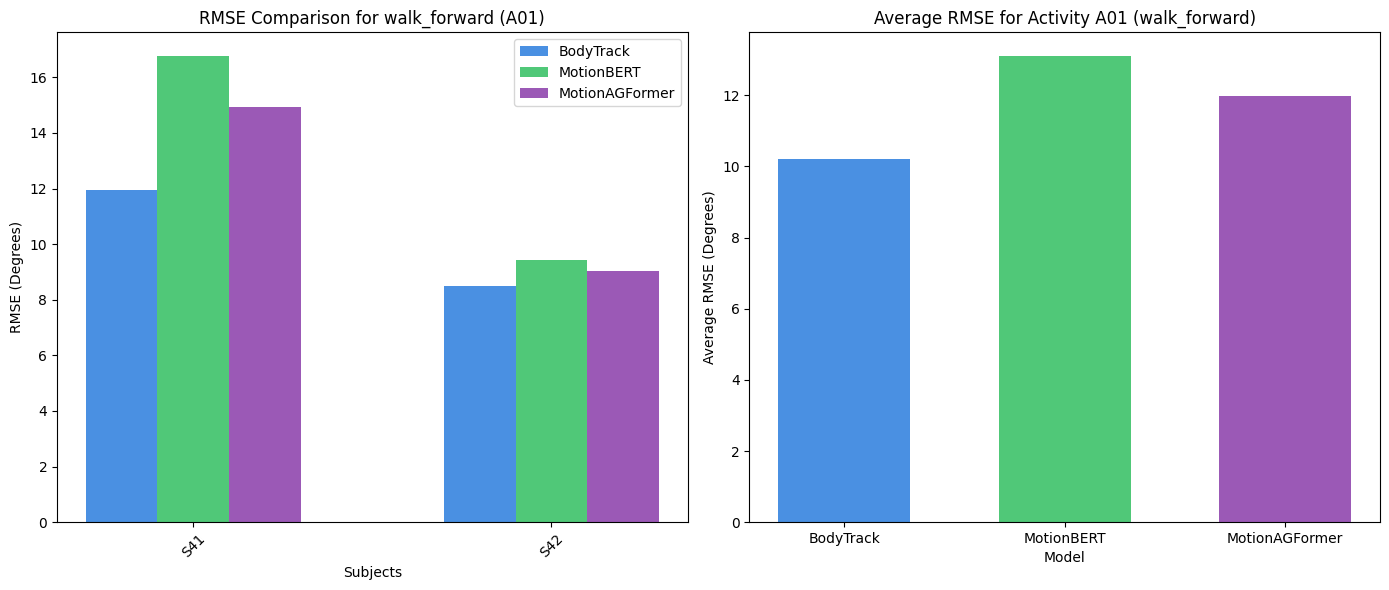

Activity: A02
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


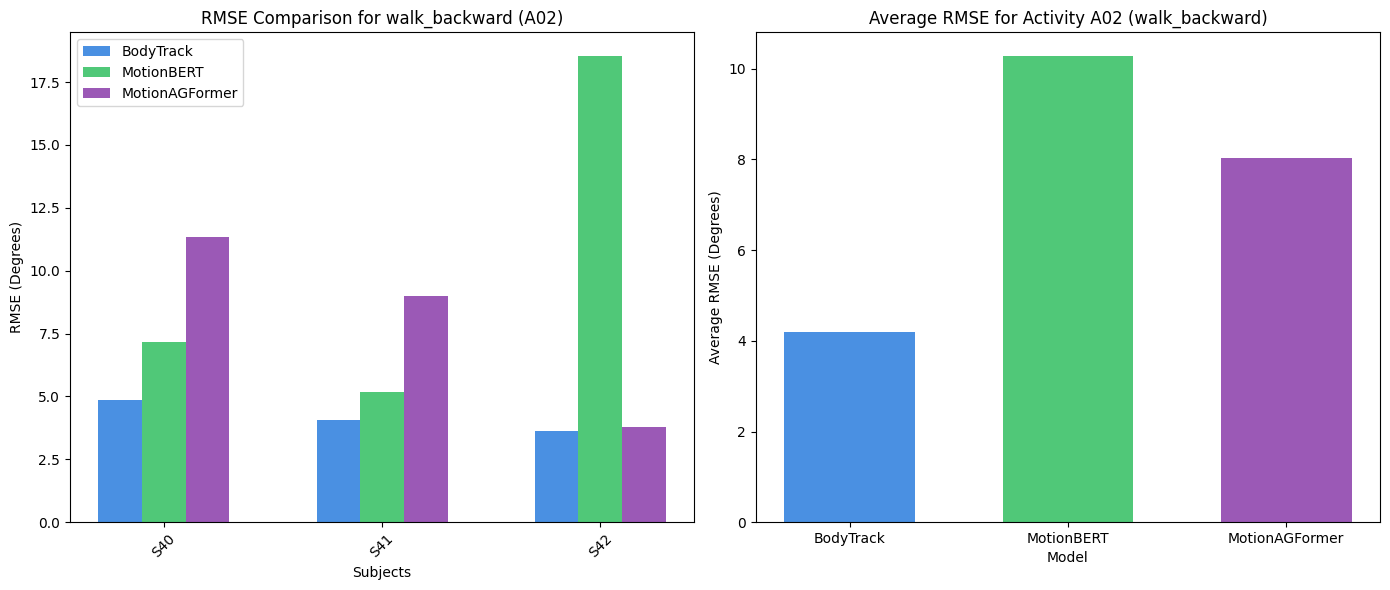

Activity: A03
Data not found for subject S41
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


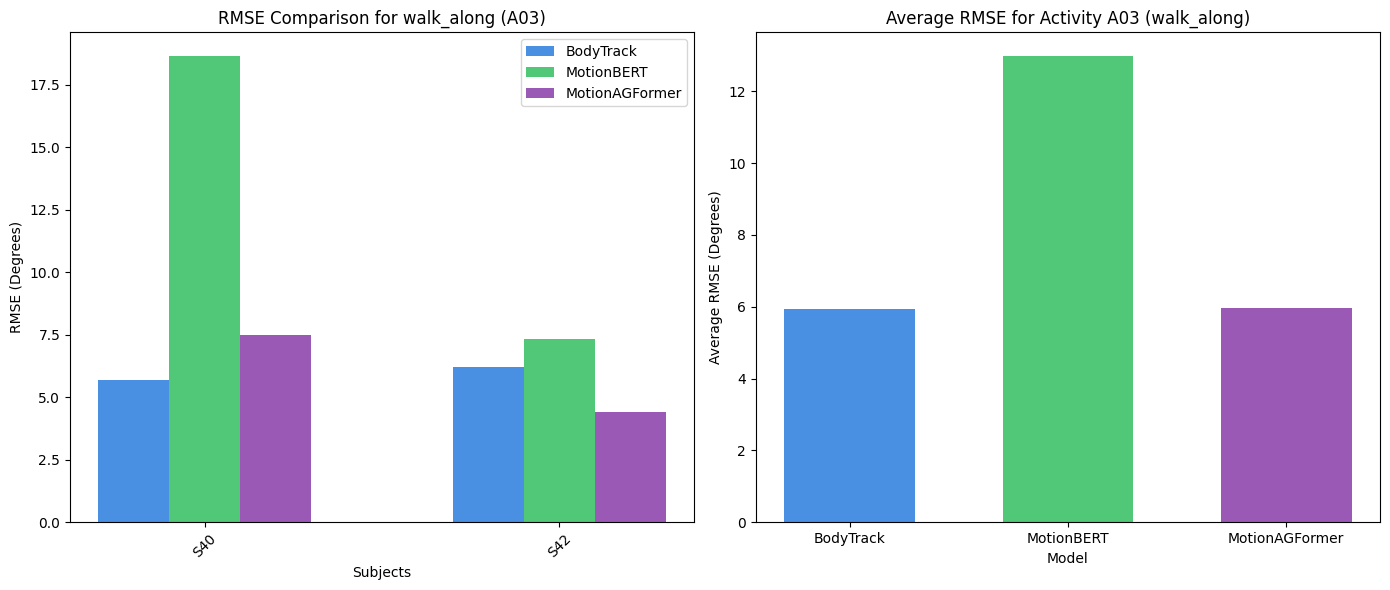

Activity: A04
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


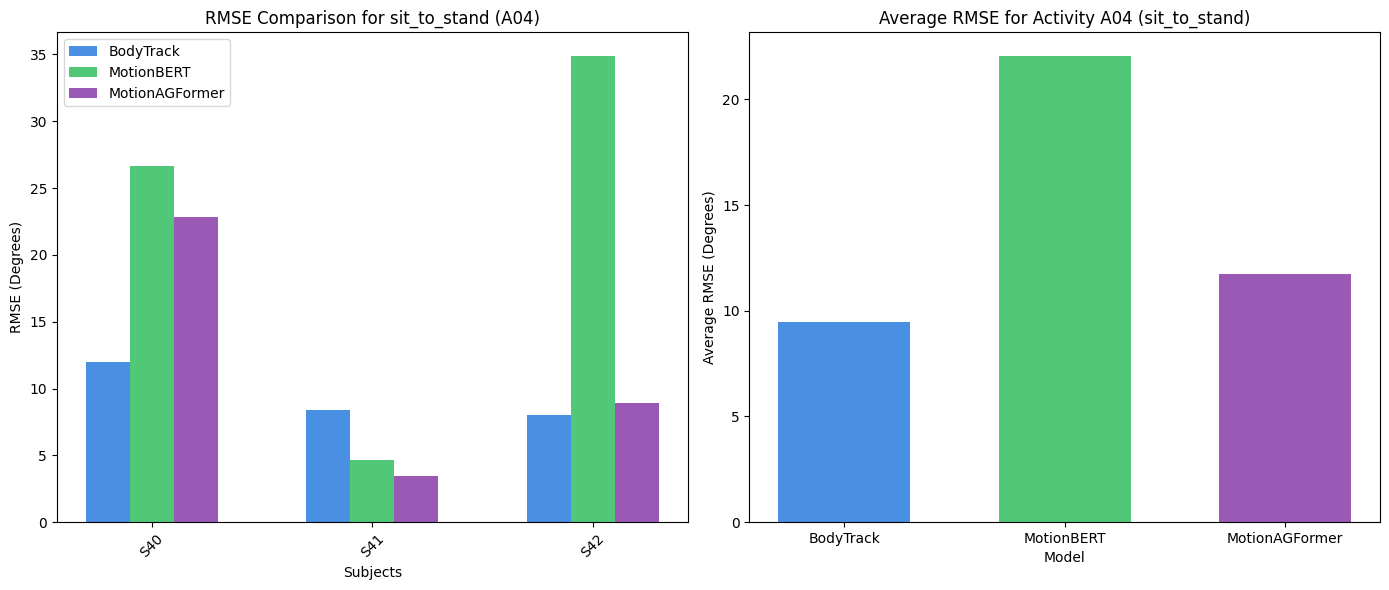

Activity: A05
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


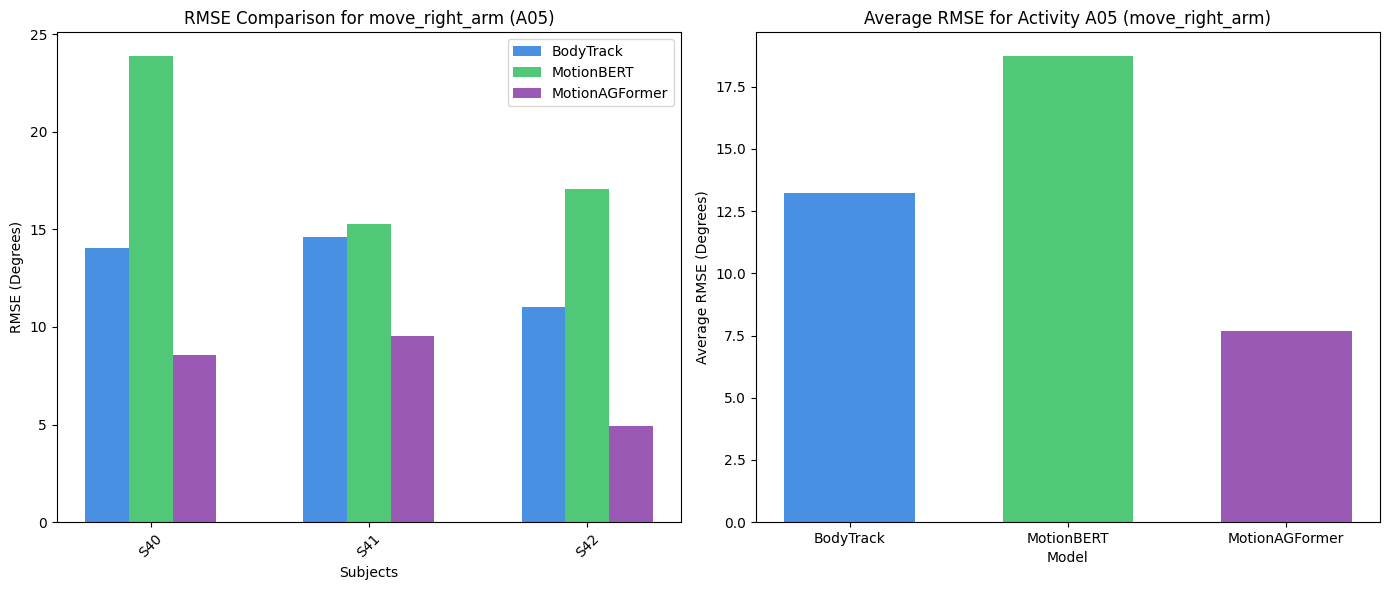

Activity: A06
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


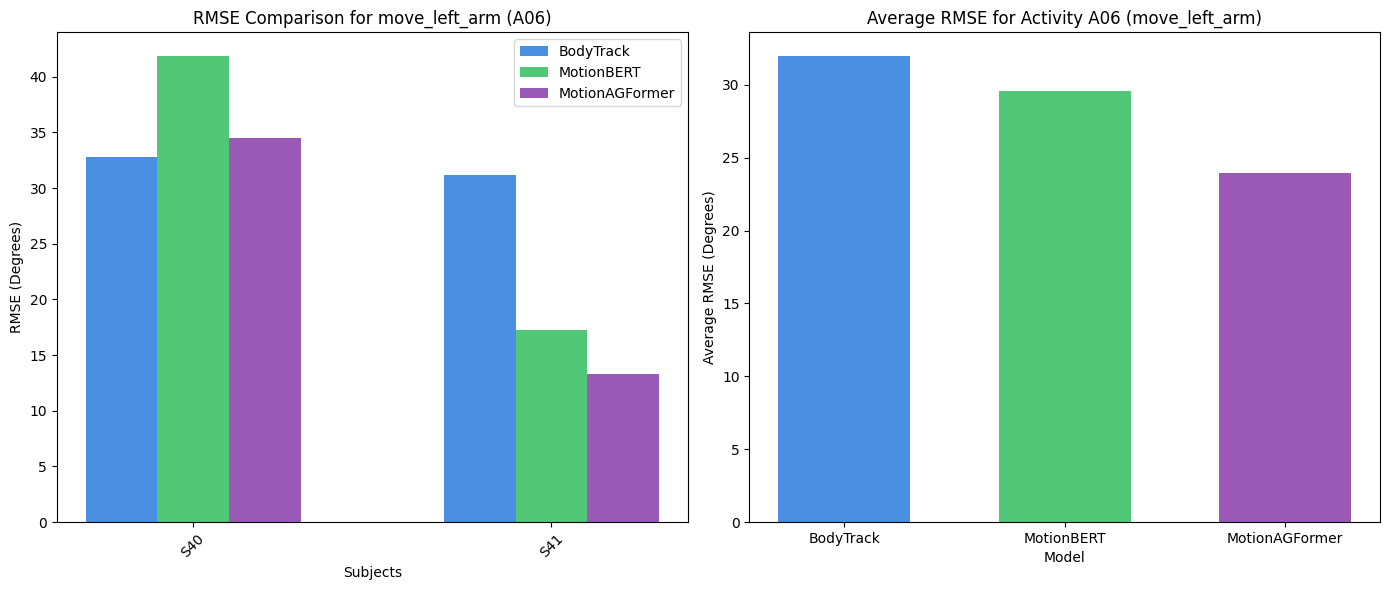

Activity: A07
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


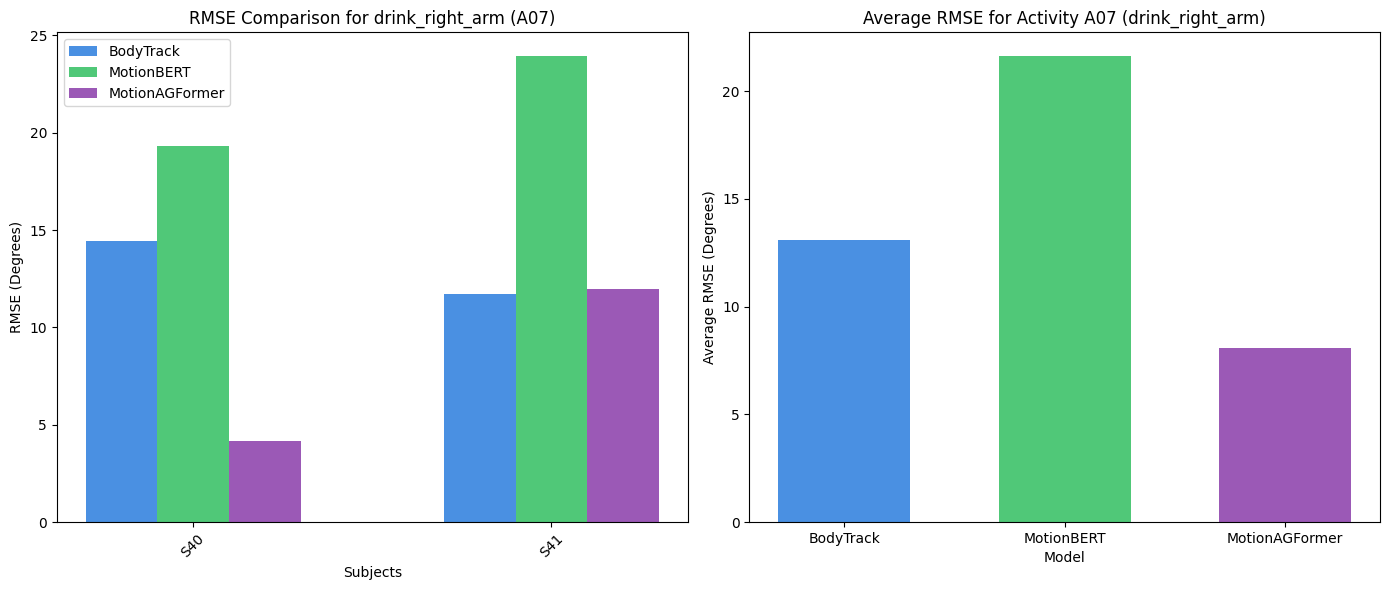

Activity: A08
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


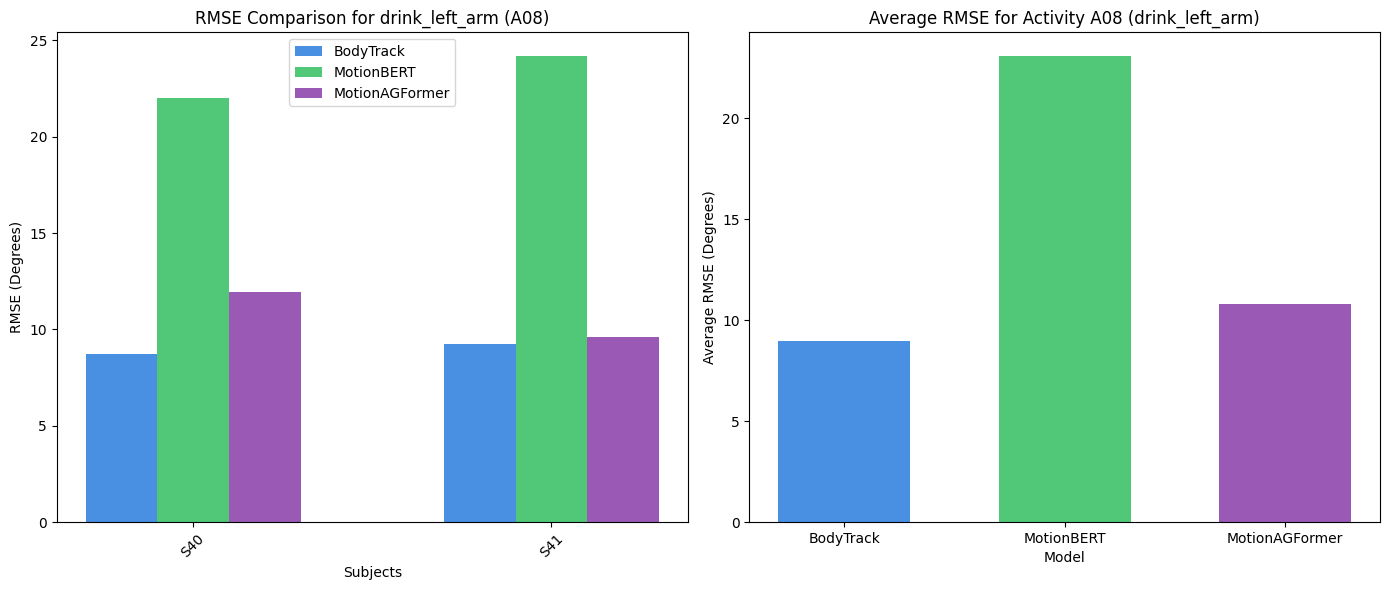

Activity: A09
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


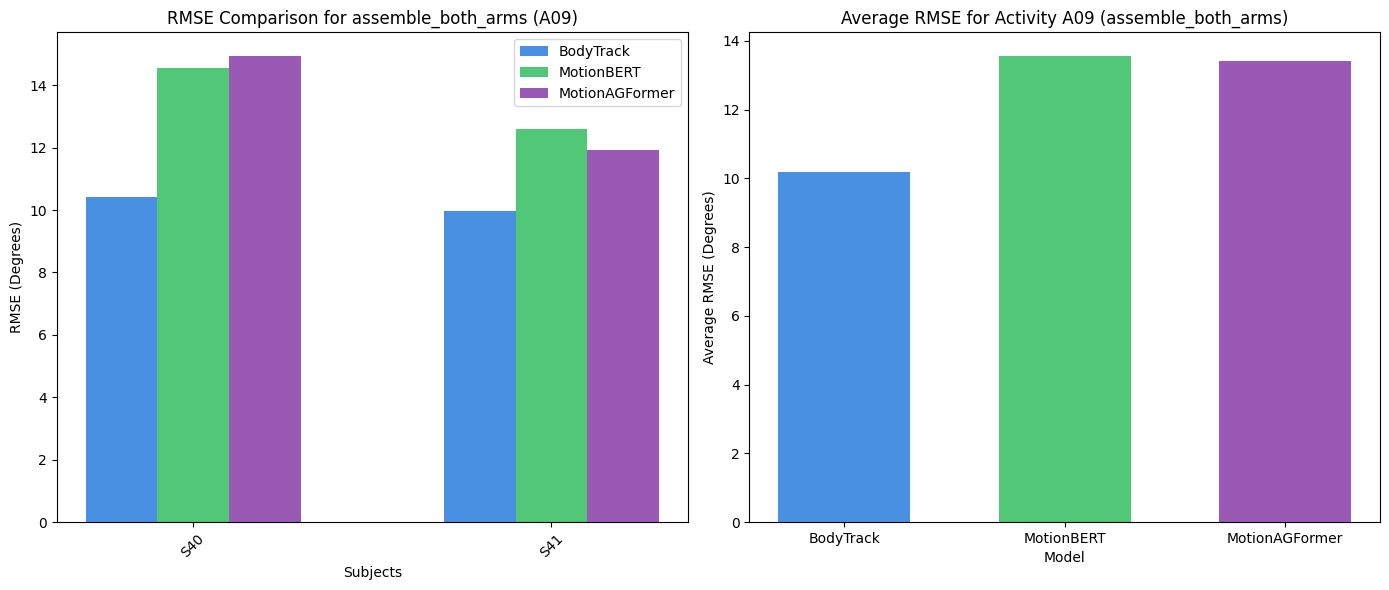

Activity: A10
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


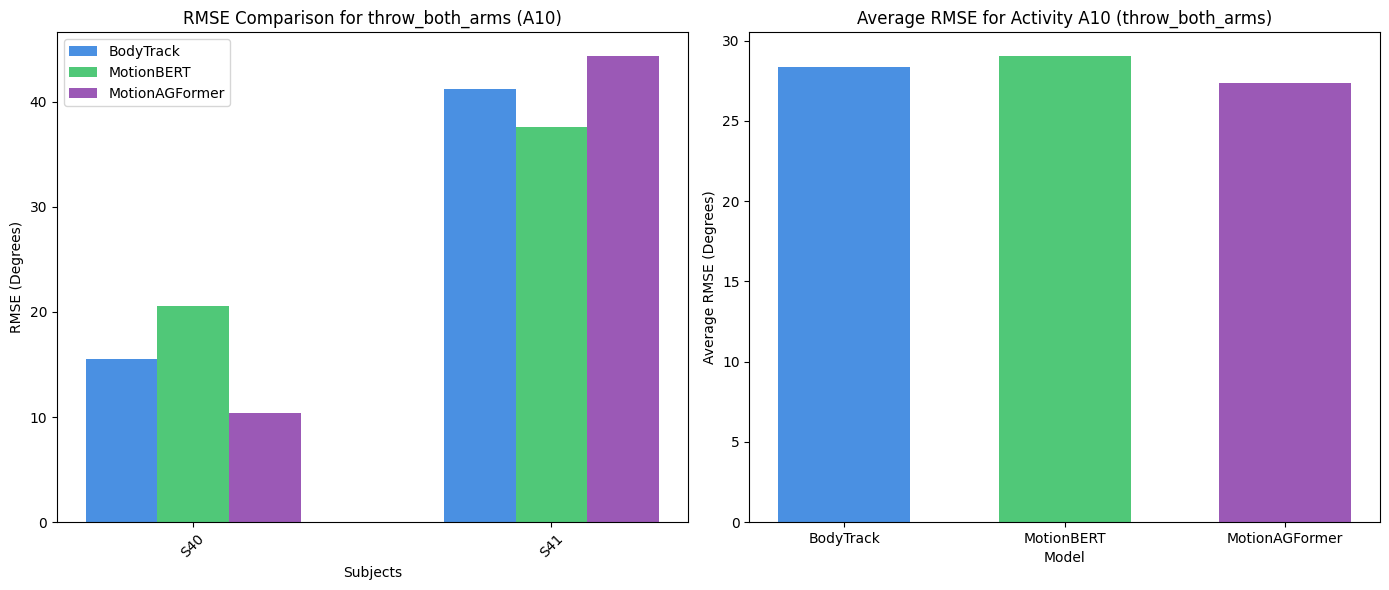

Activity: A11
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


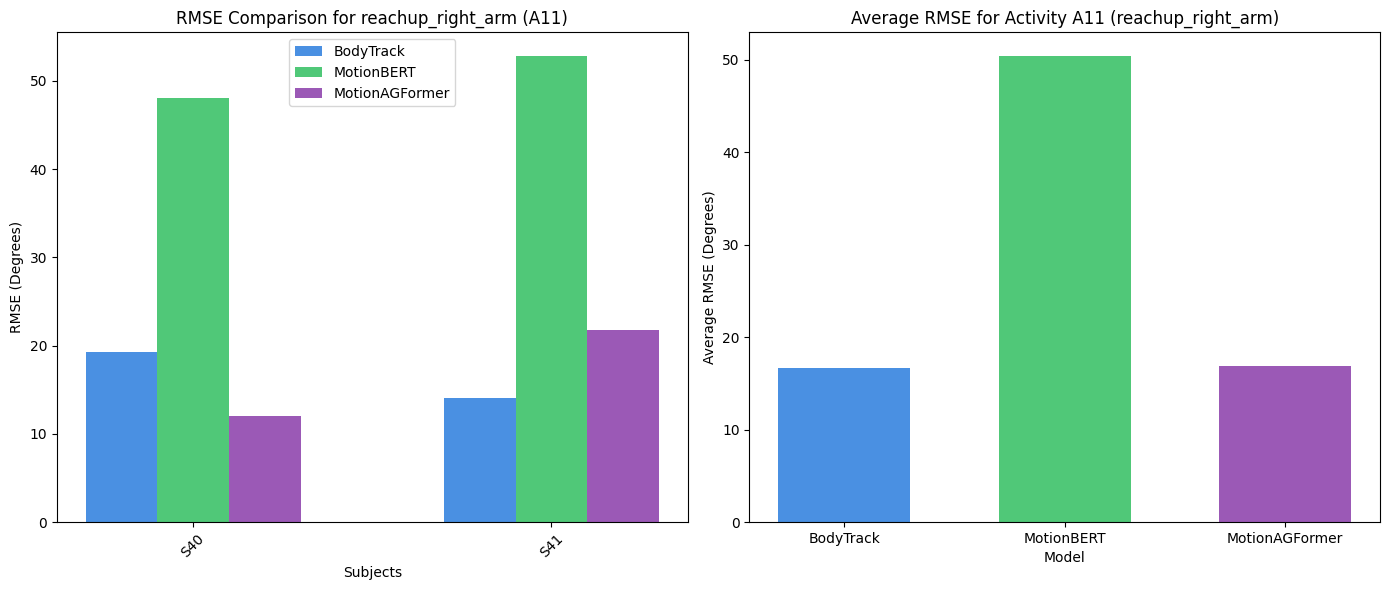

Activity: A12
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


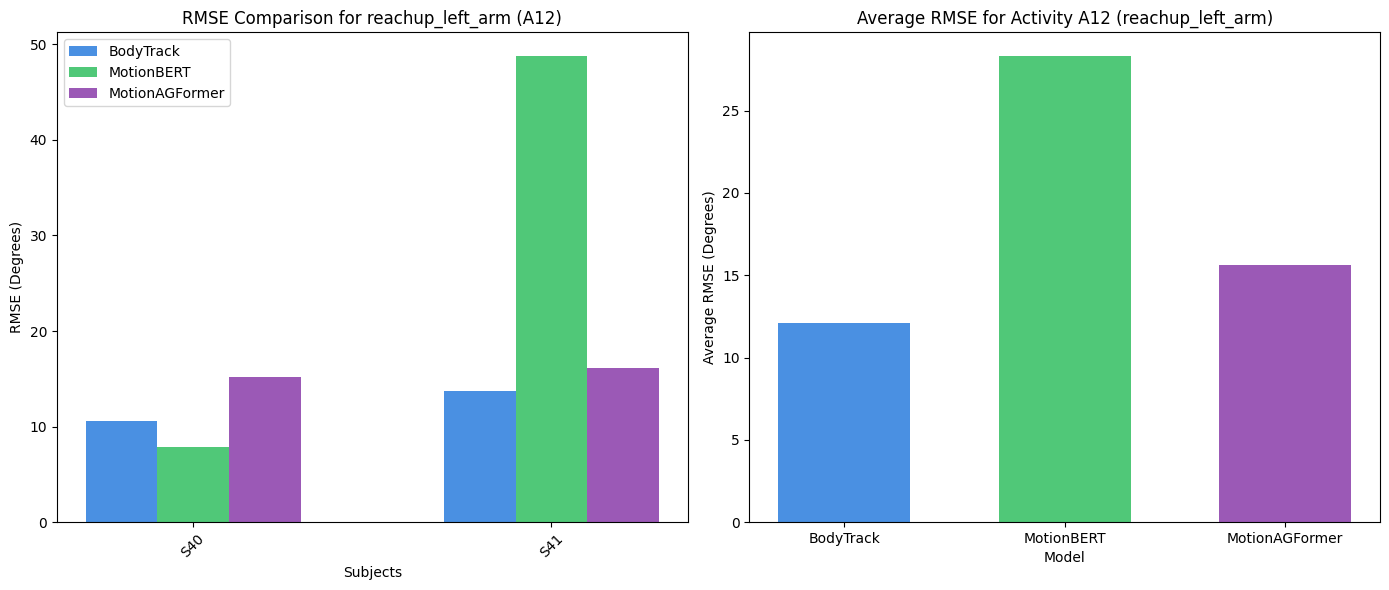

Activity: A13
Data not found for subject S42
Data not found for subject S44
Data not found for subject S46
Data not found for subject S47
Data not found for subject S48
Data not found for subject S49
Data not found for subject S50
Data not found for subject S51
Data not found for subject S52
Data not found for subject S53
Data not found for subject S54
Data not found for subject S55
Data not found for subject S56
Data not found for subject S57


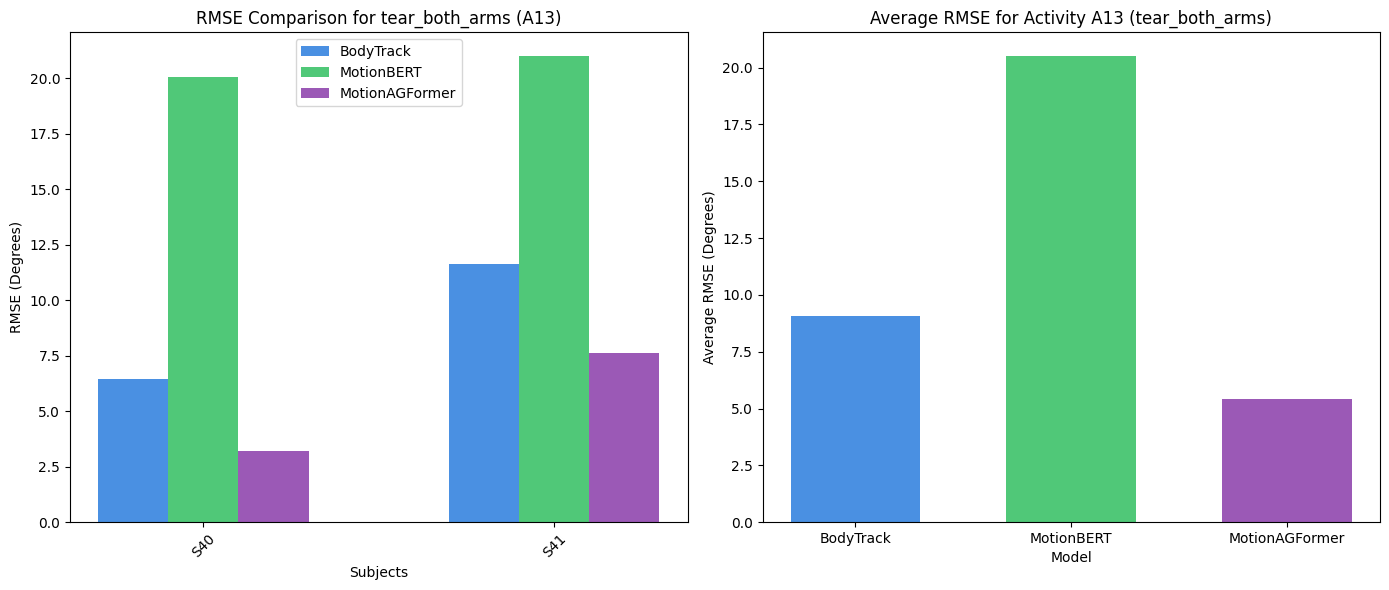

In [4]:
rmse_lists = []
index_activity = 0

csvlog='infoToSync.csv'
csvlogfile = os.path.join(out_path,csvlog)
if os.path.exists(csvlogfile):
    os.remove(csvlogfile)
for activity,legend in zip(dataset_activities,activities_legend):
    print("Activity: "+activity)
    rmse_results, best_model_counts = calculateAndPlotRMSE(
        in_path_bodytrack, in_path_motionbert, in_path_motionagformer, in_path_imus,
        selected_subjects, activity, legend, RMSE_SAMPLES=RMSE_SAMPLES, 
        MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP, FINAL_LENGTH=FINAL_LENGTH
    )